# Channel overlay scratch notebook

Loads a raw 4-channel stack, stitches the patch masks from `data/patches/`, and exports files for Fiji, Cellpose GUI, or general viewing.

**Outputs** (all under `data/processed/overlays/<stem>/`):
- `hyperstack.tif` — all 4 channels as an ImageJ hyperstack (Fiji)
- `mask_stitched.tif` — full-image label mask (Fiji)
- `patch_r*_c*_multichan.tif` + `_seg.npy` — per-patch multichannel TIFs (Cellpose GUI)
- `preview_<channel>.png` — matplotlib overlays for quick viewing

In [ ]:
import shutil
import numpy as np
import tifffile
import matplotlib.pyplot as plt
from pathlib import Path
from aquarel import load_theme

import sys
PROJECT_ROOT = Path('/Users/alicehong/projects/cellpose-biosensor')
sys.path.insert(0, str(PROJECT_ROOT))
from src.io import load_stack, split_image, stitch_masks

# ── Config ────────────────────────────────────────────────────────────────────
STACK_NAME = 'Scene-01-20260416-C3M2_Tcol_1-A01Export-01_c1-4_stack.tif'  # change this

N_ROWS = 3
N_COLS = 3

CHANNEL_NAMES = ['BFP', 'GFP', 'RFP', 'SYTOX']
CHANNEL_CMAPS = ['Blues', 'Greens', 'Reds', 'Purples']

RAW_DIR     = PROJECT_ROOT / 'data' / 'raw' / '16bit'
PATCHES_DIR = PROJECT_ROOT / 'data' / 'patches'
OUT_DIR     = PROJECT_ROOT / 'data' / 'processed' / 'overlays' / Path(STACK_NAME).stem
OUT_DIR.mkdir(parents=True, exist_ok=True)
print(f'Output → {OUT_DIR}')

Output → /Users/alicehong/projects/cellpose-biosensor/data/processed/overlays/Scene-01-20260416-C3M2_Tcol_1-A01Export-01_c1-4_stack


## Load stack and stitch masks

In [2]:
stack = load_stack(RAW_DIR / STACK_NAME)
_, H, W = stack.shape
print(f'Stack: {stack.shape}  dtype={stack.dtype}')

stem      = Path(STACK_NAME).stem
patch_dir = PATCHES_DIR / stem

# Reconstruct patch grid positions from BFP (deterministic given H, W, N_ROWS, N_COLS)
grid = split_image(stack[0], n_rows=N_ROWS, n_cols=N_COLS)

# Load each patch mask and attach to grid entry
missing = []
for p in grid:
    seg_path = patch_dir / f'patch_r{p["row"]}_c{p["col"]}_seg.npy'
    if seg_path.exists():
        dat = np.load(str(seg_path), allow_pickle=True).item()
        p['mask'] = dat['masks'].astype(np.int32)
    else:
        p['mask'] = np.zeros((p['h'], p['w']), dtype=np.int32)
        missing.append(seg_path.name)

if missing:
    print(f'Warning: no _seg.npy for {missing}')

mask_full = stitch_masks(grid, H, W)
print(f'Stitched mask: {mask_full.shape}  cells={mask_full.max()}')

Stack: (4, 6323, 6344)  dtype=uint16
Stitched mask: (6323, 6344)  cells=701


## Export: ImageJ hyperstack + label mask (Fiji)

In [3]:
# ImageJ hyperstack — open in Fiji, set LUTs per channel
hyperstack_path = OUT_DIR / 'hyperstack.tif'
tifffile.imwrite(
    str(hyperstack_path),
    stack,           # (4, H, W) uint16
    imagej=True,
    metadata={'axes': 'CYX', 'channels': 4,
              'Labels': '\\'.join(CHANNEL_NAMES)}
)
print(f'Hyperstack → {hyperstack_path}')

# Label mask — open alongside hyperstack in Fiji
# Fiji: Image > Overlay > Add Image, or open as separate window
mask_path = OUT_DIR / 'mask_stitched.tif'
tifffile.imwrite(str(mask_path), mask_full.astype(np.uint16),
                 compression='lzw', photometric='minisblack')
print(f'Mask        → {mask_path}')

Hyperstack → /Users/alicehong/projects/cellpose-biosensor/data/processed/overlays/Scene-01-20260416-C3M2_Tcol_1-A01Export-01_c1-4_stack/hyperstack.tif
Mask        → /Users/alicehong/projects/cellpose-biosensor/data/processed/overlays/Scene-01-20260416-C3M2_Tcol_1-A01Export-01_c1-4_stack/mask_stitched.tif


## Export: per-patch multichannel TIFs (Cellpose GUI)

Saves each patch as a `(4, H, W)` TIF alongside a copy of its `_seg.npy`.
Open any `patch_r*_c*_multichan.tif` in the Cellpose GUI — the masks will auto-load.

In [4]:
gui_dir = OUT_DIR / 'cellpose_gui'
gui_dir.mkdir(exist_ok=True)

for p in grid:
    r, c   = p['row'], p['col']
    y0, x0 = p['y0'], p['x0']
    h, w   = p['h'],  p['w']

    patch_all_ch = stack[:, y0:y0+h, x0:x0+w]   # (4, h, w) uint16
    tif_path = gui_dir / f'patch_r{r}_c{c}_multichan.tif'
    tifffile.imwrite(str(tif_path), patch_all_ch,
                     imagej=True,
                     metadata={'axes': 'CYX', 'channels': 4,
                                'Labels': '\\'.join(CHANNEL_NAMES)})

    # Copy _seg.npy with matching name so the GUI auto-loads it
    src_seg = patch_dir / f'patch_r{r}_c{c}_seg.npy'
    dst_seg = gui_dir  / f'patch_r{r}_c{c}_multichan_seg.npy'
    if src_seg.exists():
        shutil.copy2(str(src_seg), str(dst_seg))

print(f'Cellpose GUI patches → {gui_dir}')
print(f'Open any patch_r*_c*_multichan.tif in the GUI')
print(f'Set channel to display (e.g. chan=2 for GFP) — masks load automatically')

Cellpose GUI patches → /Users/alicehong/projects/cellpose-biosensor/data/processed/overlays/Scene-01-20260416-C3M2_Tcol_1-A01Export-01_c1-4_stack/cellpose_gui
Open any patch_r*_c*_multichan.tif in the GUI
Set channel to display (e.g. chan=2 for GFP) — masks load automatically


## Preview: per-channel PNGs with mask overlay

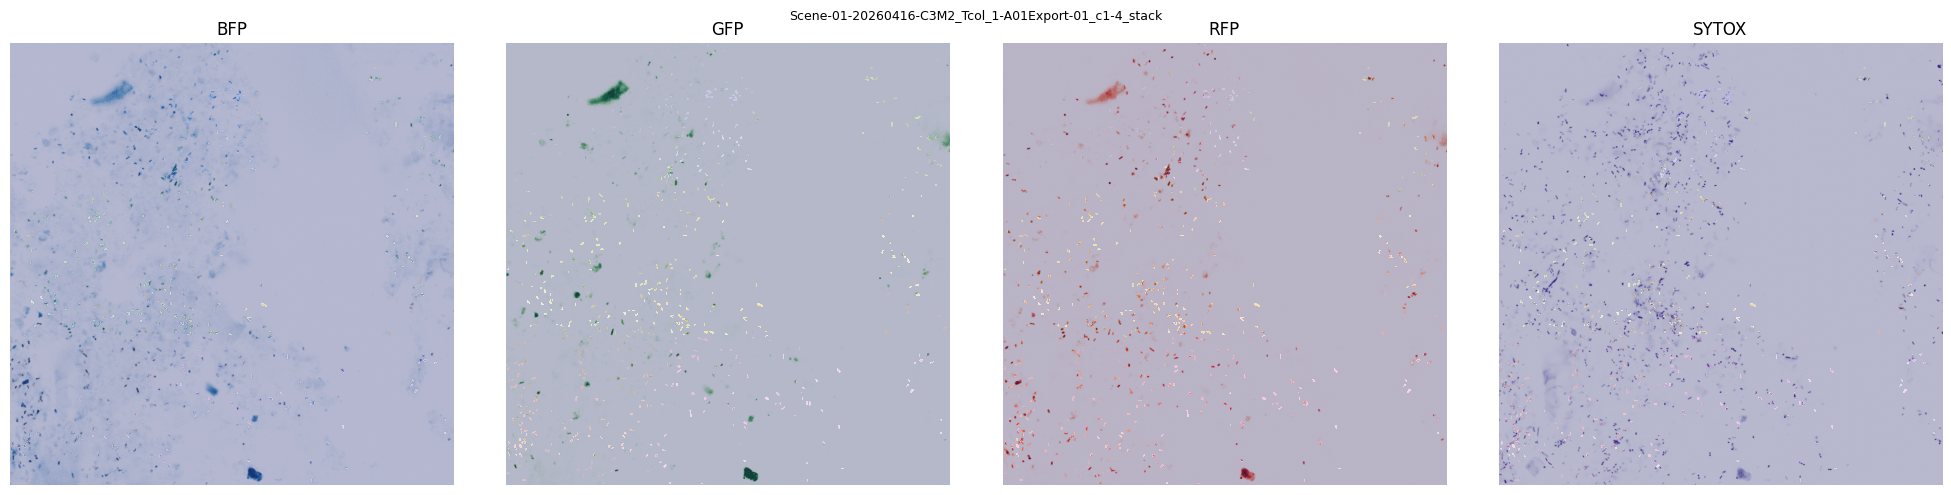

Preview → /Users/alicehong/projects/cellpose-biosensor/data/processed/overlays/Scene-01-20260416-C3M2_Tcol_1-A01Export-01_c1-4_stack/preview_all_channels.png


In [5]:
from cellpose import utils

def norm(img, plow=1, phigh=99.9):
    lo, hi = np.percentile(img, [plow, phigh])
    return np.clip((img.astype(float) - lo) / (hi - lo + 1e-6), 0, 1)

def show_mask(ax, img_norm, mask, cmap):
    ax.imshow(img_norm, cmap=cmap, vmin=0, vmax=1)
    if mask.max() > 0:
        ax.imshow(mask, cmap='tab20b', alpha=0.35, interpolation='nearest')

SCALE = 8   # downsample factor for preview (full image is ~6300×6300)

mask_ds = mask_full[::SCALE, ::SCALE]

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for i, (name, cmap, ax) in enumerate(zip(CHANNEL_NAMES, CHANNEL_CMAPS, axes)):
    ch_ds = stack[i, ::SCALE, ::SCALE]
    show_mask(ax, norm(ch_ds), mask_ds, cmap)
    ax.set_title(name)
    ax.axis('off')

fig.suptitle(stem, fontsize=9)
fig.tight_layout()
png_path = OUT_DIR / 'preview_all_channels.png'
fig.savefig(str(png_path), dpi=150, bbox_inches='tight')
plt.show()
print(f'Preview → {png_path}')

## Preview: individual channel close-ups (patch level)

In [ ]:
# Pick a patch to inspect closely — change row/col as needed
INSPECT_ROW = 0
INSPECT_COL = 0

p = next(x for x in grid if x['row'] == INSPECT_ROW and x['col'] == INSPECT_COL)
y0, x0, h, w = p['y0'], p['x0'], p['h'], p['w']
patch_mask   = mask_full[y0:y0+h, x0:x0+w]

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for i, (name, cmap, ax) in enumerate(zip(CHANNEL_NAMES, CHANNEL_CMAPS, axes)):
    ch_patch = stack[i, y0:y0+h, x0:x0+w]
    show_mask(ax, norm(ch_patch), patch_mask, cmap)
    ax.set_title(f'{name}  (r{INSPECT_ROW}c{INSPECT_COL})')
    ax.axis('off')

fig.tight_layout()
png_path = OUT_DIR / f'preview_patch_r{INSPECT_ROW}_c{INSPECT_COL}.png'
fig.savefig(str(png_path), dpi=150, bbox_inches='tight')
plt.show()
print(f'Preview → {png_path}')